# Single-Cell Analysis NORMAL TISSUE  – June 2026 

End-to-end preprocessing pipeline for paired **GEX + TCR + ADT** data from
sorted CD8 TIL samples. 

**Outline**
1. Imports
2. Sample info
3. Data loading (GEX + TCR per sample)
4. MuData assembly
5. Gene-ID annotation (mouse, Ensembl)
6. ADT modality extraction
7. Filtering genes
8. Quality-control metrics
9. Normalisation & HVG selection
10. Dimensionality reduction & clustering
11. Metadata annotation
12. AIRR-based subsetting & final save
13. Save mdata

## 1 · Imports

In [1]:
# Standard library
import os
from pathlib import Path
from functools import partial

# Numerical / data
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation

# Single-cell ecosystem
import anndata as ad
import mudata as mu
import scanpy as sc
import scirpy as ir

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

# Optional / downstream
import decoupler as dc


alt.data_transformers.enable('vegafusion')

sc.settings.verbosity = 1 

## 2 · Sample info

Define all samples with their experimental group and treatment condition.
TIL (tumour-infiltrating lymphocyte) 2021 cohort.

In [2]:
samples = {
    "10mix1": {"group": "ctrl",},
    "10mix1": {"group": "ctrl"},
    "11mix1": {"group": "effector"},
    "11mix1": {"group": "effector"},
    "GF1": {"group": "GF"},
    "GF2": {"group": "GF"},
}   

## 3 · Data Loading

Read one **GEX** (gene expression) and one **TCR** (VDJ) AnnData per sample
from the CellRanger multi output directories.

In [3]:
samples = {
    "10mix1": {"group": "ctrl"},
    "10mix2": {"group": "ctrl"},
    "11mix1": {"group": "effector"},
    "11mix2": {"group": "effector"},
    "GF1": {"group": "GF"},
    "GF2": {"group": "GF"},
}

adatas_tcr_2019 = {}
adatas_gex_2019 = {}

for sample, sample_meta in samples.items():

    adata_gex = sc.read_10x_h5(
        f"/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/2019-10-29_sorted_cd8/analyses_icbi/{sample}/outs/per_sample_outs/{sample}/count/sample_filtered_feature_bc_matrix.h5",
        gex_only=False,
    )

    adata_tcr = ir.io.read_10x_vdj(
        f"/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/2019-10-29_sorted_cd8/analyses_icbi/{sample}/outs/multi/vdj_t/all_contig_annotations.csv"
    )

    adata_gex.var_names_make_unique()

    adatas_tcr_2019[sample] = adata_tcr
    adatas_gex_2019[sample] = adata_gex

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/airr/schema.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream
Non-standard locus name: None 
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/_co

### Concatenate per-sample AnnData objects

In [4]:
adata_tcr_2019 = ad.concat(adatas_tcr_2019, index_unique="_")

In [5]:
adata_gex_2019 = ad.concat(adatas_gex_2019, index_unique="_")

## 4 · MuData Assembly

Combine GEX and TCR (AIRR) into a single `MuData` container.

In [6]:
mdata = mu.MuData({"gex": adata_gex_2019, "airr": adata_tcr_2019})

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## 5 · Gene-ID Annotation

Map gene symbols → Ensembl IDs (mouse / mm10) using **mygene**.
This is required for downstream tools that expect Ensembl IDs.

In [7]:
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()

genes = mdata["gex"].var_names.tolist()

res = mg.querymany(
    genes,
    scopes="symbol",
    fields="ensembl.gene",
    species="mouse",
    as_dataframe=True
)

res = res.reset_index().rename(columns={"query": "gene_symbol"})

res.columns

2026-06-09 10:56:12 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-06-09 10:56:12 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-06-09 10:56:12 | [INFO] querying 1-1000 ...
2026-06-09 10:56:14 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-06-09 10:56:15 | [INFO] querying 1001-2000 ...
2026-06-09 10:56:16 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-06-09 10:56:17 | [INFO] querying 2001-3000 ...
2026-06-09 10:56:18 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-06-09 10:56:19 | [INFO] querying 3001-4000 ...
2026-06-09 10:56:20 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-06-09 10:56:21 | [INFO] querying 4001-5000 ...
2026-06-09 10:56:22 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-06-09 10:56:23 | [INFO] querying 5001-6000

Index(['gene_symbol', '_id', '_score', 'ensembl.gene', 'notfound', 'ensembl'], dtype='object')

In [8]:
# Case 1: if column is called "ensembl.gene"
if "ensembl.gene" in res.columns:
    mapping = (
        res.dropna(subset=["ensembl.gene"])
        .drop_duplicates("gene_symbol")
        .set_index("gene_symbol")["ensembl.gene"]
    )

# Case 2: if column is called "ensembl"
elif "ensembl" in res.columns:
    def extract_ensembl(x):
        if isinstance(x, dict):
            return x.get("gene")
        elif isinstance(x, list):
            return x[0].get("gene") if len(x) > 0 else None
        else:
            return None

    res["gene_ids"] = res["ensembl"].apply(extract_ensembl)

    mapping = (
        res.dropna(subset=["gene_ids"])
        .drop_duplicates("gene_symbol")
        .set_index("gene_symbol")["gene_ids"]
    )

In [9]:
mdata["gex"].var["gene_ids"] = mdata["gex"].var_names.map(mapping)
mdata["gex"].var["feature_types"] = "Gene Expression"

## 6 · ADT Modality Extraction

Split antibody-capture (ADT) features into a dedicated `mdata['adt']` modality.

In [10]:
mask = (
    mdata["gex"].var["gene_ids"].isna() &
    mdata["gex"].var.index.str.contains("_TotalSeqC")
)

mdata["gex"].var.loc[mask, "feature_types"] = "Antibody Capture"

In [11]:
mdata.mod["adt"] = mdata["gex"][
    :,
    mdata["gex"].var["feature_types"] == "Antibody Capture"
].copy()

In [12]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [13]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [14]:
def update_columns_condition(row):
    
    if row["sample_id"] == "GF1":
        row["condition"] = "GF"
    elif row["sample_id"] == "GF2":
        row["condition"] = "GF"
    elif row["sample_id"] == "10mix1":
        row["condition"] = "ctrl"
    elif row["sample_id"] == "10mix2":
        row["condition"] = "ctrl"
    elif row["sample_id"] == "11mix1":
        row["condition"] = "effector"
    elif row["sample_id"] == "11mix2":
        row["condition"] = "effector"

    return row

In [15]:
mdata["gex"].obs["sample_id"] = (
    mdata["gex"].obs_names
    .str.split("_")
    .str[-1]
)

In [16]:
mdata["gex"].obs = mdata["gex"].obs.apply(update_columns_condition, axis=1)

In [17]:
mdata["gex"].obs["sample_id"] = mdata["gex"].obs["sample_id"].replace({
    "10mix1": "ctrl1",
    "10mix2": "ctrl2",
    "11mix1": "effector1",
    "11mix2": "effector2",
})

In [18]:
mdata["gex"].obs

,sample_id,condition
AAACCTGAGTCTTGCA-1_10mix1,ctrl1,ctrl
AAACCTGAGTTAAGTG-1_10mix1,ctrl1,ctrl
AAACCTGCAGGATCGA-1_10mix1,ctrl1,ctrl
AAACCTGCATAACCTG-1_10mix1,ctrl1,ctrl
AAACCTGCATACCATG-1_10mix1,ctrl1,ctrl
...,...,...
TTTGCGCTCGGTGTTA-1_GF2,GF2,GF
TTTGTCAAGGCTAGCA-1_GF2,GF2,GF
TTTGTCAAGTGCCAGA-1_GF2,GF2,GF
TTTGTCAAGTTGTCGT-1_GF2,GF2,GF


## 9 · Quality-Control Metrics

- Counts layer contains raw counts

Flag mitochondrial, ribosomal, and haemoglobin genes,
then compute per-cell QC statistics.

In [19]:
mdata["gex"].layers["counts"] = mdata["gex"].X.copy()

In [20]:
mdata["gex"].var["mito"] = mdata["gex"].var_names.str.startswith("mt")
mdata["gex"].var["ribo"] = mdata["gex"].var_names.str.startswith("rb")
mdata["gex"].var["hb"] = mdata["gex"].var_names.str.startswith("hb")
sc.pp.calculate_qc_metrics(
    mdata["gex"],
    qc_vars=["mito", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)

In [21]:
mdata

MuData object with n_obs × n_vars = 18506 × 32285
  3 modalities
    gex:	18506 x 32285
      obs:	'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	'counts'
    airr:	15207 x 0
      obsm:	'airr'
    adt:	18506 x 0
      var:	'gene_ids', 'feature_types'

... storing 'sample_id' as categorical
... storing 'condition' as categorical
... storing 'gene_ids' as categorical
... storing 'feature_types' as categorical


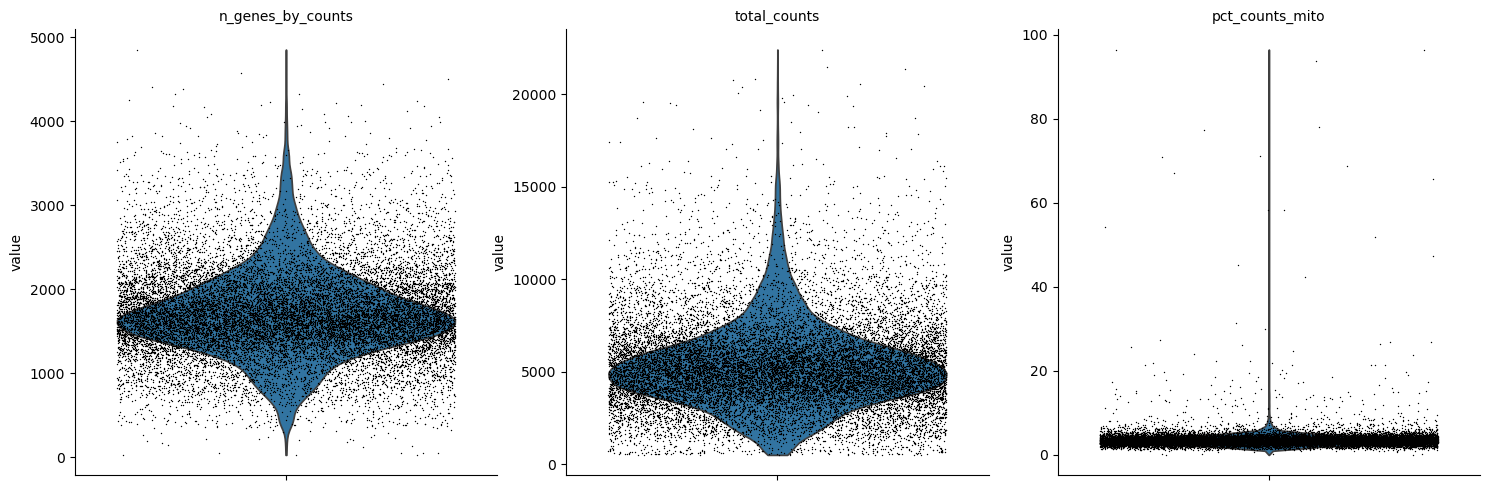

In [22]:
sc.pl.violin(
    mdata["gex"],
    ["n_genes_by_counts", "total_counts", "pct_counts_mito"],
    jitter=0.4,
    multi_panel=True,
)

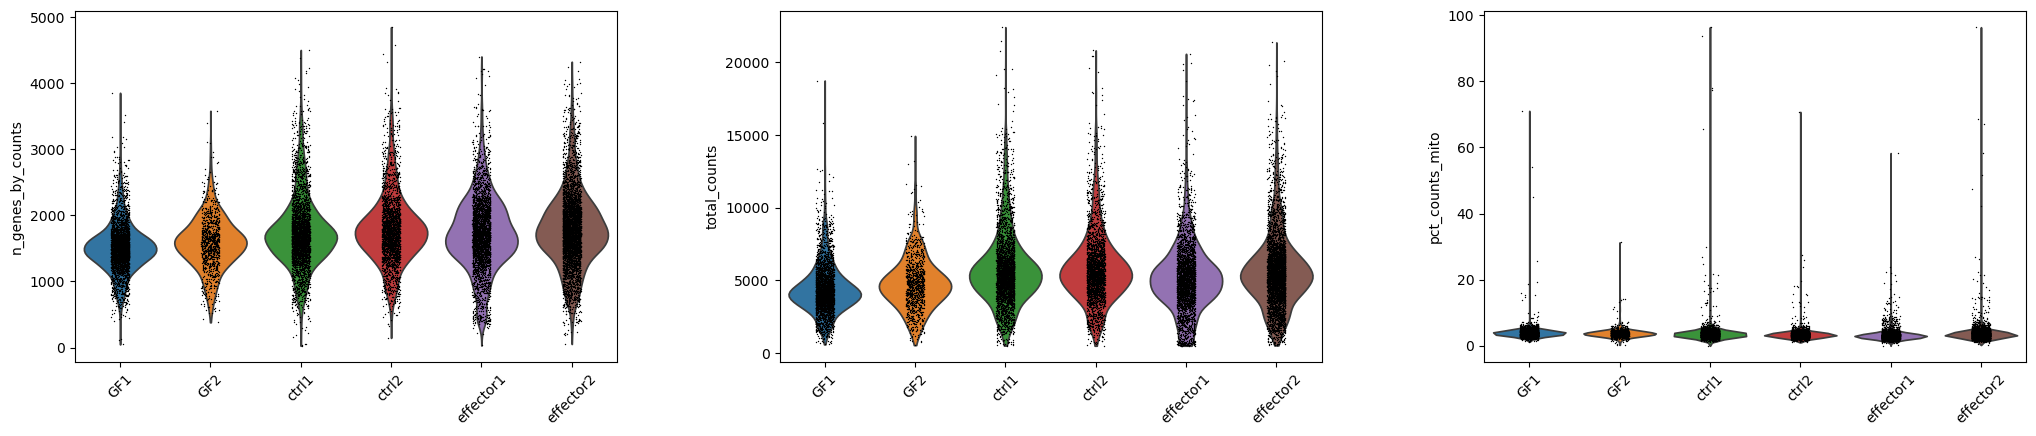

In [23]:
sc.pl.violin(
    mdata["gex"],
    keys=["n_genes_by_counts", "total_counts", "pct_counts_mito"],
    groupby="sample_id",
    rotation=45,
    multi_panel=True,
)

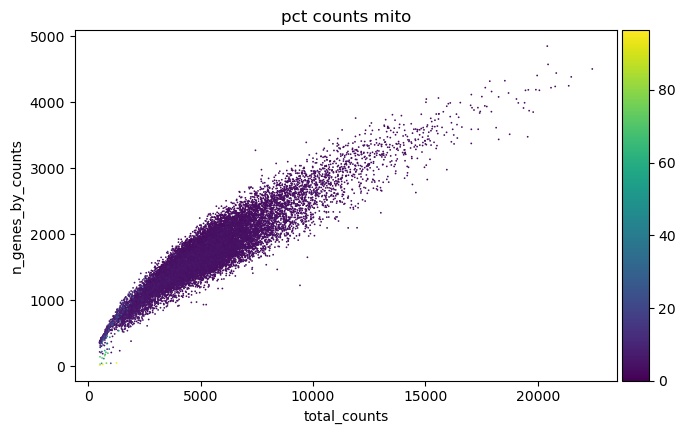

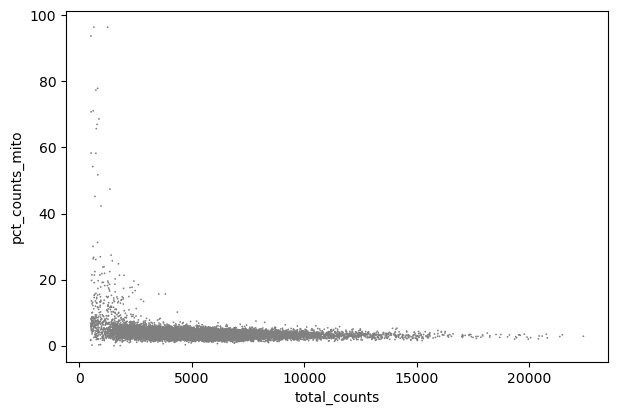

In [24]:
sc.pl.scatter(
    mdata["gex"],
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mito",
)

sc.pl.scatter(
    mdata["gex"],
    x="total_counts",
    y="pct_counts_mito",
)

## 10 · Normalisation & Highly Variable Genes

Normalise library size, log-transform, and select the top 1000 highly_variable_genes

### Create counts layer with RAW counts

In [25]:
# Saving count data
mdata["gex"].layers["counts"] = mdata["gex"].X.copy()

In [26]:
sc.pp.normalize_total(mdata["gex"])
sc.pp.log1p(mdata["gex"])

In [27]:
sc.pp.highly_variable_genes(mdata["gex"], n_top_genes=1000, batch_key="sample_id")

In [28]:
sc.tl.pca(mdata["gex"])

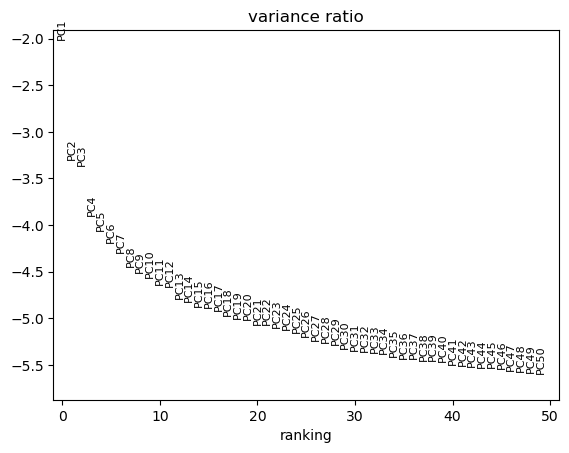

In [29]:
sc.pl.pca_variance_ratio(mdata["gex"], n_pcs=50, log=True)

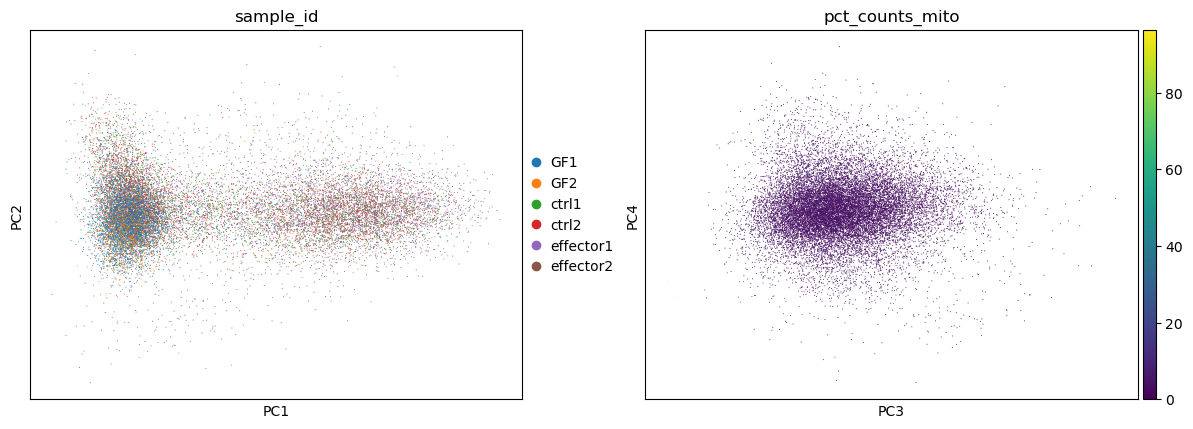

In [30]:
sc.pl.pca(
    mdata["gex"],
    color=["sample_id",  "pct_counts_mito"],
    dimensions=[(0, 1), (2, 3)],
    ncols=2,
    size=2,
)

## 7 · Filtering genes

In [32]:
sc.pp.filter_cells(mdata["gex"], min_genes=100)
sc.pp.filter_genes(mdata["gex"], min_cells=3)

## 11 · Dimensionality Reduction & Leiden Clustering

Build a kNN graph, embed with UMAP, and compute Leiden clusters at three
resolutions for exploratory inspection.

In [33]:
sc.pp.neighbors(mdata["gex"])

I0000 00:00:1780996006.414125 2916489 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780996006.473413 2916489 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780996008.151578 2916489 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [34]:
sc.tl.umap(mdata["gex"])

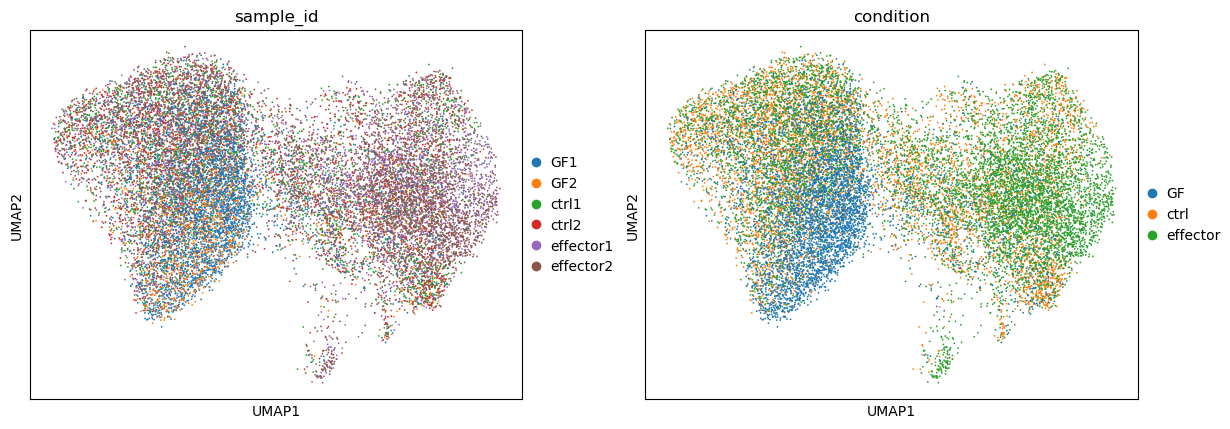

In [35]:
sc.pl.umap(mdata["gex"], color = ["sample_id","condition"])

In [36]:
sc.tl.leiden(mdata["gex"], resolution=1, key_added="rna_leiden")

/tmp/ipykernel_2916489/3344562552.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(mdata["gex"], resolution=1, key_added="rna_leiden")


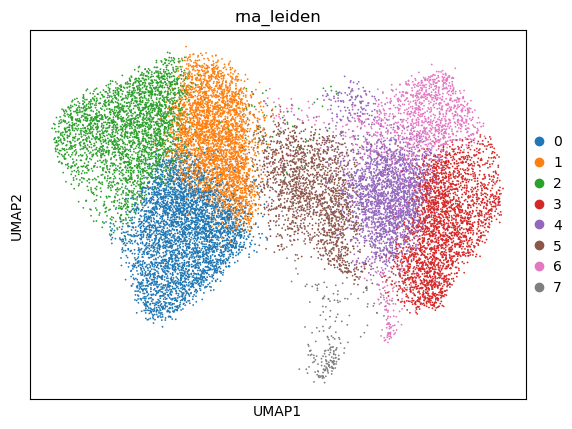

In [37]:
sc.pl.umap(mdata["gex"], color = ["rna_leiden"])

### Filter out doublets

In [38]:
sc.pp.scrublet(mdata["gex"], batch_key="sample_id")

adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.


... storing 'sample_id' as categorical
... storing 'condition' as categorical


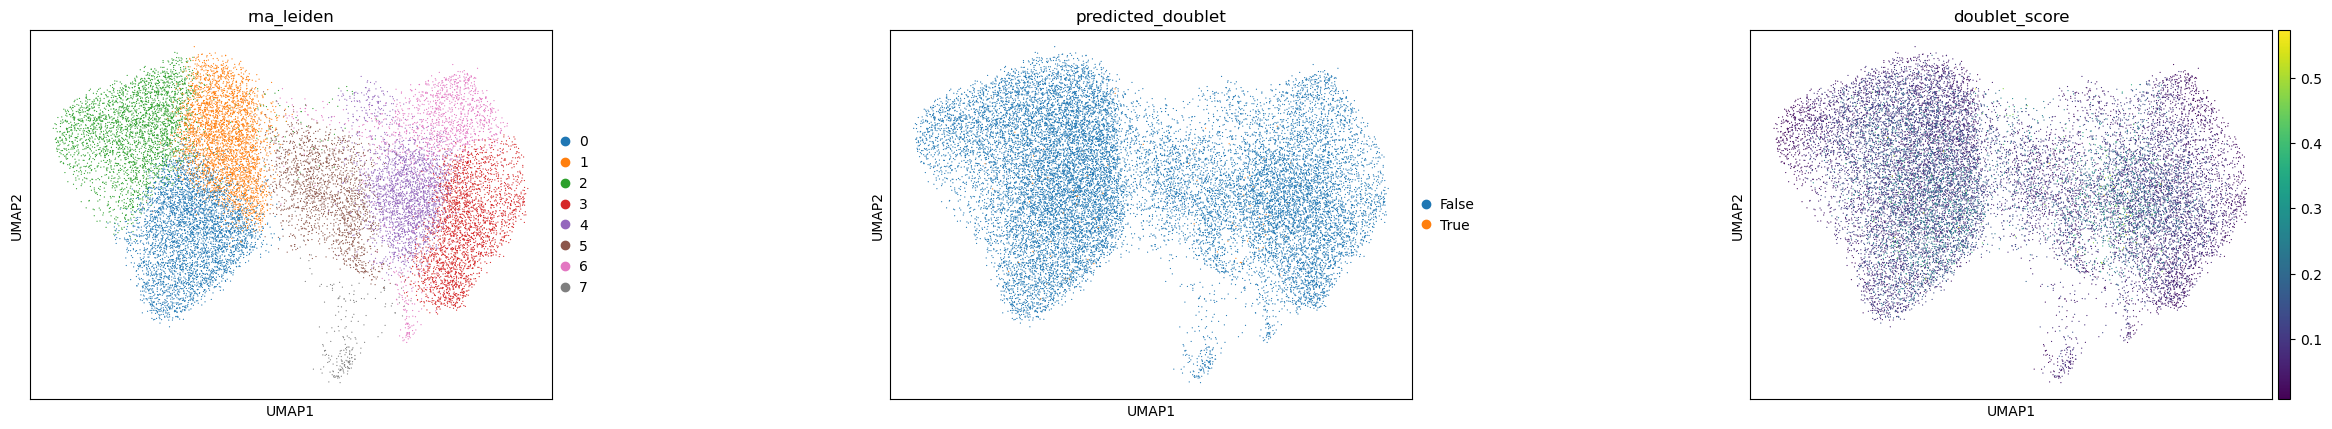

In [39]:
sc.pl.umap(
    mdata["gex"],
    color=["rna_leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

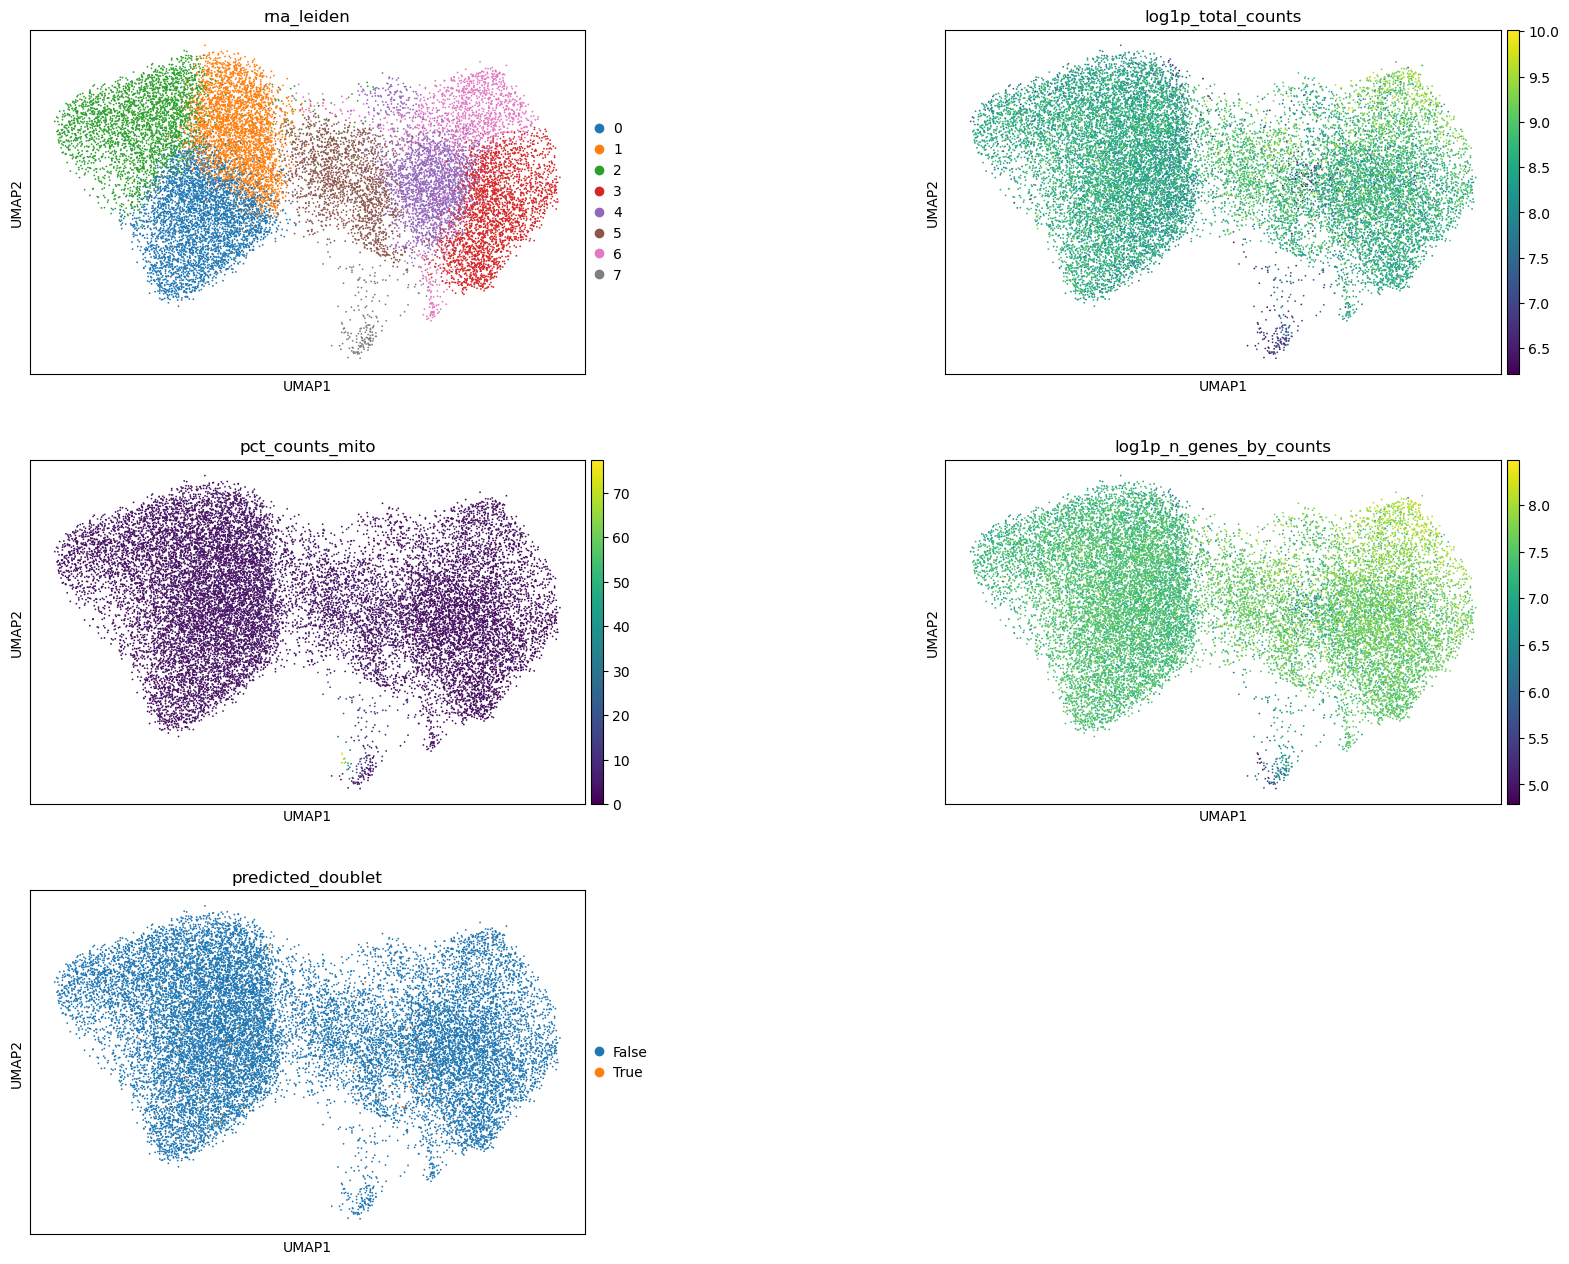

In [40]:
sc.pl.umap(
    mdata["gex"],
    color=["rna_leiden", "log1p_total_counts", "pct_counts_mito", "log1p_n_genes_by_counts","predicted_doublet"],
    wspace=0.5,
    ncols=2,
)

In [41]:
mdata["gex"].obs.predicted_doublet.value_counts()

predicted_doublet
False    18416
True        83
Name: count, dtype: int64

### Visualize QC metrics

In [46]:
mdata["adt"].obs["sample_id"] = mdata["gex"].obs["sample_id"]

In [47]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## 12 · AIRR-Based Subsetting & Final MuData

Restrict the ADT modality to cells that also have TCR data (AIRR), then
sync the MuData object.

In [48]:
# cells present in AIRR
airr_cells = mdata["airr"].obs_names

# subset ADT to those cells
mdata.mod["adt"] = mdata["adt"][airr_cells, :].copy()

In [49]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## 13 · Save Mudata


In [50]:
import pandas as pd

for mod in mdata.mod.keys():
    adata = mdata[mod]

    # fix obs columns
    for col in adata.obs.columns:
        if adata.obs[col].dtype == "object":
            adata.obs[col] = adata.obs[col].astype(str)

    # fix var columns
    for col in adata.var.columns:
        if adata.var[col].dtype == "object":
            adata.var[col] = adata.var[col].fillna("").astype(str)

mdata.update()
mdata.write("001_create_mudata_normal.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: Fro